In [1]:
""""
@author: Shreyash Garg, created Feb 2026 ibmi spring school
"""
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
from torchvision.models.segmentation import deeplabv3_resnet50
import torch
import torch.functional as F
import numpy as np
import requests
import cv2
import torchvision
from PIL import Image
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


In [2]:
"""
Feature extractor
"""

class ResnetFeatureExtractor(torch.nn.Module):
    def __init__(self, model):
        super(ResnetFeatureExtractor, self).__init__()
        self.model = model
        self.feature_extractor = torch.nn.Sequential(*list(self.model.children())[:-1])
                
    def __call__(self, x):
        return self.feature_extractor(x)[:, :, 0, 0]

"""
Function to fetch and do minimal preprocessing on image from an online source
"""

def get_image_from_url(url):
    """A function that gets a URL of an image, 
    and returns a numpy image and a preprocessed
    torch tensor ready to pass to the model """

    img = np.array(Image.open(requests.get(url, stream=True).raw))
    img = cv2.resize(img, (512, 512))
    rgb_img_float = np.float32(img) / 255
    input_tensor = preprocess_image(rgb_img_float,
                                   mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
    return img, rgb_img_float, input_tensor


def get_image(path):
    """A function that gets a path of an image, 
    and returns a numpy image and a preprocessed
    torch tensor ready to pass to the model """

    img = np.array(Image.open(path))
    img = cv2.resize(img, (512, 512))
    rgb_img_float = np.float32(img) / 255
    input_tensor = preprocess_image(rgb_img_float,
                                   mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
    return img, rgb_img_float, input_tensor

In [3]:
"""
Load the pretrained resnet50 model (pretrained on imagenet 1k with 1000 classes)
"""

# https://gist.github.com/aaronpolhamus/964a4411c0906315deb9f4a3723aac57
resnet = torchvision.models.resnet50(pretrained=True)
resnet.eval()
model = ResnetFeatureExtractor(resnet)

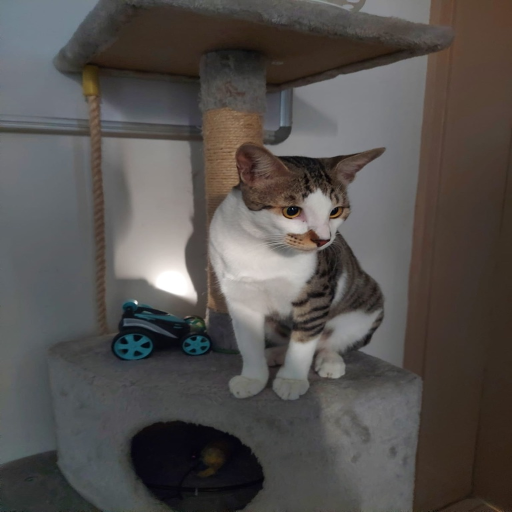

In [5]:
"""
The image to explain
"""
# cat_img, cat_img_float, cat_tensor = get_image_from_url("https://images.pexels.com/photos/2061057/pexels-photo-2061057.jpeg?_gl=1*i3bt1h*_ga*MTA3MjgwMTQyMS4xNzcyMzgxNzc0*_ga_8JE65Q40S6*czE3NzIzODE3NzMkbzEkZzEkdDE3NzIzODE3OTUkajM4JGwwJGgw")
# cat_concept_features = model(cat_tensor)[0, :]

# Image.fromarray(cat_img)

cat_img, cat_img_float, cat_tensor = get_image("example_images/my_cat.jpeg")
cat_concept_features = model(cat_tensor)[0, :]

Image.fromarray(cat_img)


In [6]:
"""
Instead of using ClassifierOutputTarget, the following function will similarity to various classes
"""

class SimilarityToConceptTarget:
    def __init__(self, features):
        self.features = features
    
    def __call__(self, model_output):
        cos = torch.nn.CosineSimilarity(dim=0)
        return cos(model_output, self.features)
    
target_layers = [resnet.layer4[-1]]
cat_targets = [SimilarityToConceptTarget(cat_concept_features)]



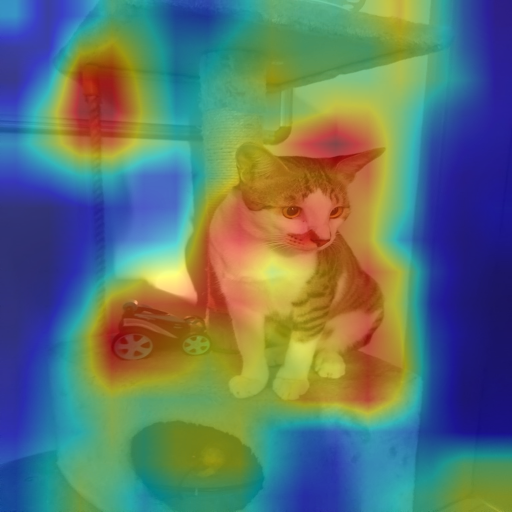

In [7]:
"""
Using GradCAM to explain model predictions
"""

# Where is the cat in the image
with GradCAM(model=model,
             target_layers=target_layers) as cam:
    cat_grayscale_cam = cam(input_tensor=cat_tensor,
                        targets=cat_targets)[0, :]

cat_cam_image = show_cam_on_image(cat_img_float, cat_grayscale_cam, use_rgb=True)
Image.fromarray(cat_cam_image)